## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,roc_curve,roc_auc_score,classification_report

## Dataset Loading

In [39]:
df=pd.read_csv("train_csv.csv")

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## data understanding

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
df.shape

(614, 13)

## data preprocessing

In [9]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
df.drop("Loan_ID",axis=1,inplace=True)

In [11]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [12]:
for column in df.columns:
    df[column]=df[column].fillna(df[column].mode()[0])

In [13]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## Encoding

In [15]:
le = LabelEncoder()
for column in df.select_dtypes(include="object").columns:
    df[column]=le.fit_transform(df[column])
  

In [16]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,120.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## separating input and output


In [17]:
X=df.drop("Loan_Status",axis=1)
y=df["Loan_Status"]

In [18]:
print(X.shape)

(614, 11)


In [19]:
print(y.shape)

(614,)


## Split training and testing data

In [20]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
print("Training_data",X_train.shape)
print("Testing_data",X_test.shape)

Training_data (491, 11)
Testing_data (123, 11)


## Model Building

In [22]:
model=LogisticRegression(max_iter=1000)

## Training the model

In [23]:
model.fit(X_train,y_train)
print("model trained successfully")

model trained successfully


C:\Users\Aditi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Training accuracy

In [24]:
train_pred=model.predict(X_train)
train_accuracy=accuracy_score(
    y_train,
    train_pred
)
print("Training Accuracy:",
      round(train_accuracy*100,2),"%")

Training Accuracy: 79.84 %


## Testing accuracy

In [25]:
test_pred=model.predict(X_test)
test_accuracy=accuracy_score(
    y_test,
    test_pred
)
print("Testing_accuracy:",round(test_accuracy*100,2),"%")


Testing_accuracy: 86.18 %


## Evaluation metrics

In [26]:
print("Classification Report")
print(classification_report(
    y_test,
    test_pred,
    target_names=["Rejected","Approved"]
))

Classification Report
              precision    recall  f1-score   support

    Rejected       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



Confusion Matrix:
[[22 16]
 [ 1 84]]


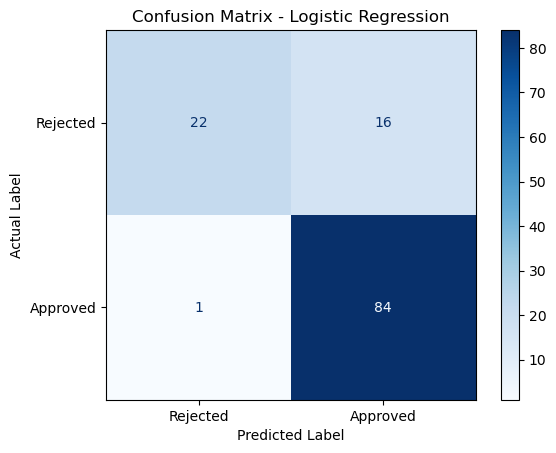

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, test_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Roc curve and Roc-Auc

ROC-AUC Score: 0.7889


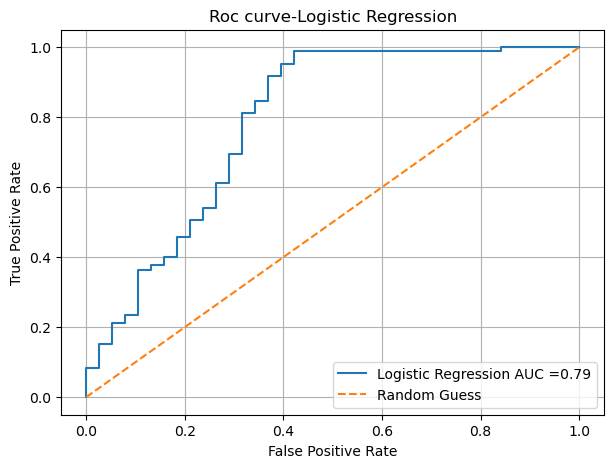

In [28]:
#Probability of Approved class
y_test_prob=model.predict_proba(X_test)[:,1]
#Roc values
fpr,tpr,thresholds=roc_curve(y_test,y_test_prob)
# AUC score
auc_score=roc_auc_score(y_test,y_test_prob)
print("ROC-AUC Score:",round(auc_score,4))
plt.figure(figsize=(7,5))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression AUC ={auc_score:.2f}"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Guess"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc curve-Logistic Regression")
plt.legend()
plt.grid()
plt.show()
    

## new predictions

In [37]:
import pandas as pd

# Take input from user
gender = input("Enter Gender (Male/Female): ").strip().title()
married = input("Enter Married (Yes/No): ").strip().title()
dependents = input("Enter Dependents (0/1/2/3+): ").strip()
education = input("Enter Education (Graduate/Not Graduate): ").strip()
self_employed = input("Enter Self Employed (Yes/No): ").strip().title()

applicant_income = float(input("Enter Applicant Income: "))
coapplicant_income = float(input("Enter Coapplicant Income: "))
loan_amount = float(input("Enter Loan Amount: "))
loan_amount_term = float(input("Enter Loan Amount Term: "))
credit_history = float(input("Enter Credit History (1/0): "))
property_area = input("Enter Property Area (Urban/Semiurban/Rural): ").strip().title()


# Create input DataFrame
input_data = pd.DataFrame({
    "Gender": [gender],
    "Married": [married],
    "Dependents": [dependents],
    "Education": [education],
    "Self_Employed": [self_employed],
    "ApplicantIncome": [applicant_income],
    "CoapplicantIncome": [coapplicant_income],
    "LoanAmount": [loan_amount],
    "Loan_Amount_Term": [loan_amount_term],
    "Credit_History": [credit_history],
    "Property_Area": [property_area]
})


# Convert categorical values
input_data["Gender"] = input_data["Gender"].map({
    "Male": 1,
    "Female": 0
})

input_data["Married"] = input_data["Married"].map({
    "Yes": 1,
    "No": 0
})

input_data["Dependents"] = input_data["Dependents"].map({
    "0": 0,
    "1": 1,
    "2": 2,
    "3+": 3
})

input_data["Education"] = input_data["Education"].map({
    "Graduate": 0,
    "Not Graduate": 1
})

input_data["Self_Employed"] = input_data["Self_Employed"].map({
    "Yes": 1,
    "No": 0
})

input_data["Property_Area"] = input_data["Property_Area"].map({
    "Urban": 2,
    "Semiurban": 1,
    "Rural": 0
})


# Check for missing values
if input_data.isnull().any().any():
    print("\nInvalid input detected.")
    print("Please enter values exactly as shown in the prompts.")
    print(input_data)
else:
    # Arrange columns in training order
    input_data = input_data[X_train.columns]

    # Make prediction
    prediction = model.predict(input_data)[0]

    print("\nPrediction:")

    if prediction == 1:
        print("Loan Approved")
    else:
        print("Loan Rejected")

Enter Gender (Male/Female):  Male
Enter Married (Yes/No):  Yes
Enter Dependents (0/1/2/3+):  0
Enter Education (Graduate/Not Graduate):  Graduate
Enter Self Employed (Yes/No):  Yes
Enter Applicant Income:  10000
Enter Coapplicant Income:  20000
Enter Loan Amount:  150000
Enter Loan Amount Term:  360
Enter Credit History (1/0):  1
Enter Property Area (Urban/Semiurban/Rural):  Urban



Prediction:
Loan Rejected


## model saving

In [29]:
import pickle
# save the trained Logistic Regression model
with open("loan_approval_model.pkl","wb") as file:
    pickle.dump(model,file)
print("Model saved successfully!")

Model saved successfully!
